
# **Lab #1: การจัดการข้อมูลพื้นฐาน**
## **วัตถุประสงค์**
1. เรียนรู้การใช้งาน Python เบื้องต้นสำหรับการจัดการข้อมูล
2. เรียนรู้การใช้ไลบรารีสำคัญ เช่น Pandas และ GeoPandas
3. เรียนรู้การอ่าน/เขียนและสำรวจข้อมูลทางภูมิศาสตร์ (GeoData)

---
หมายเหตุ บางครั้งอาจจะเจอ Bug. ขอจงอย่าย่อท้อ ให้ใช้ทรัพยากรที่มีอยู่ในการจัดการแก้ไขปัญหา เช่น  Gemini หรือ ChatGPT แต่ทั้งนี้ต้องทำความเข้าใจกับคำตอบที่ได้ เพราะบางครั้ง AI ก็ให้คำตอบแบบงงๆ



## **1. การเริ่มต้นใช้งาน Google Colab**
### **1.1 เชื่อมต่อ Google Drive**
ก่อนอื่น ให้เชื่อมต่อ Google Drive เพื่อจัดเก็บข้อมูลของคุณ
    

In [13]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive



### **1.2 ติดตั้งไลบรารีที่จำเป็น**
ติดตั้งไลบรารีที่จำเป็นสำหรับการจัดการข้อมูลและการวิเคราะห์ข้อมูลภูมิศาสตร์
    

In [14]:

!pip install pandas geopandas matplotlib



## **2. การจัดการข้อมูลตารางด้วย Pandas**
### **2.1 สร้าง DataFrame ตัวอย่าง**
ลองสร้าง DataFrame ข้อมูลประชากรของประเทศในภูมิภาค ASEAN
    

In [15]:

import pandas as pd

# สร้าง DataFrame ตัวอย่าง
data = {
    'ประเทศ': ['ไทย', 'ลาว', 'กัมพูชา', 'เวียดนาม'],
    'ประชากร (ล้าน)': [69.8, 7.1, 16.5, 97.3],
    'พื้นที่ (ตร.กม.)': [513120, 236800, 181035, 331210]
}
df = pd.DataFrame(data)

# แสดงข้อมูล
print(df)

# คำนวณความหนาแน่นประชากร
df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df['ประชากร (ล้าน)'] * 1_000_000 / df['พื้นที่ (ตร.กม.)']
print(df)


     ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)
0       ไทย            69.8            513120
1       ลาว             7.1            236800
2   กัมพูชา            16.5            181035
3  เวียดนาม            97.3            331210
     ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  ความหนาแน่นประชากร (คน/ตร.กม.)
0       ไทย            69.8            513120                      136.030558
1       ลาว             7.1            236800                       29.983108
2   กัมพูชา            16.5            181035                       91.142597
3  เวียดนาม            97.3            331210                      293.771323



### **2.2 การอ่านไฟล์ข้อมูล CSV**
- ให้นักศึกษาหาข้อมูลที่น่าสนใจในรูปแบบ  CSV
- โหลด File .csv เข้า google drive ของนักศึกษา
- จากนั้นให้ไปดูใน file_path ในรูป โฟลเดอร์ ด้านซ้ายบน
    

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd # Import the pandas library

# ตัวอย่างการอ่านไฟล์ CSV
file_path = '/content/drive/MyDrive/data.csv'
geo_df = pd.read_csv(file_path)

# ตรวจสอบข้อมูล
print(geo_df.head())
print(geo_df.info())

   Year Phuket visitor Phuket Revenue (m baht)
0  1988        884,293                     NaN
1  1989        971,683                6,705.89
2  1990      1,254,215                8,574.27
3  1991      1,208,594               10,699.99
4  1992      1,633,496               33,891.17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Year                     37 non-null     int64 
 1   Phuket visitor           37 non-null     object
 2   Phuket Revenue (m baht)  36 non-null     object
dtypes: int64(1), object(2)
memory usage: 1020.0+ bytes
None


**ตอบคำถาม 5 คะแนน**

จงใช้สันชาตญาณนักภูมิศาสตร์ อธิบายข้อมูลที่ได้ ว่าเป็นข้อมูลเกี่ยวกับอะไร

ตอบ จำนวนนักท่องเที่ยวและรายได้ของจังหวัดภูเก็ต


## **3. การจัดการข้อมูลภูมิศาสตร์ด้วย GeoPandas** 5 คะแนน
### **3.1 การอ่าน Shapefile และแสดงผล**
ใช้ข้อมูล Shapefile ที่มีขอบเขตและมีประชากร อาจจะหาจากแหล่งข้อมูลที่ เป็น Opendata เช่น
https://data.humdata.org/dataset/worldpop-population-density-for-thailand

    

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'tha_admin_boundaries.shp.zip': 'tha_admin0' (default), 'tha_admin1', 'tha_admin2', 'tha_admin3', 'tha_adminlines', 'tha_adminpoints'. Specify layer parameter to avoid this warning.
  result = read_func(


  iso2 iso3 adm0_name adm0_name1 adm0_name2 adm0_name3 adm0_pcode   valid_on  \
0   TH  THA  Thailand  ประเทศไทย       None       None         TH 2022-01-22   

  valid_to version      area_sqkm lang lang1 lang2 lang3 adm0_ref_n  \
0      NaT     v01  515415.588703   en    th  None  None   Thailand   

   center_lat  center_lon                                           geometry  
0   13.039207  101.699821  MULTIPOLYGON (((99.96093 20.46482, 99.9613 20....  
EPSG:4326


<Axes: >

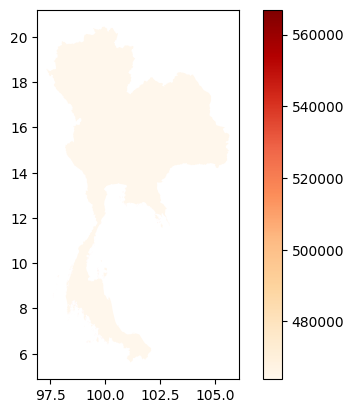

In [18]:
import geopandas as gpd

# อ่านไฟล์ Shapefile (GeoPandas สามารถอ่านไฟล์ .zip ที่มี Shapefile อยู่ข้างในได้โดยตรง)
# หากมีหลายเลเยอร์ในไฟล์ .zip และต้องการเลเยอร์เฉพาะ ให้ระบุ layer='ชื่อเลเยอร์' เพิ่มเติม
shapefile_path = '/content/drive/MyDrive/tha_admin_boundaries.shp.zip'
geo_data = gpd.read_file(shapefile_path)

# แสดงข้อมูลเบื้องต้น
print(geo_data.head())
print(geo_data.crs)

# แสดงผลข้อมูลบนแผนที่ โดยใช้คอลัมน์ 'area_sqkm' ซึ่งมีอยู่ในข้อมูล
# หากต้องการใช้คอลัมน์อื่น ต้องตรวจสอบชื่อคอลัมน์ที่ถูกต้องจาก geo_data.columns หรือ geo_data.head()
geo_data.plot(column='area_sqkm', cmap='OrRd', legend=True)


## **4. การแสดงผลข้อมูล**
### **4.1 สร้างกราฟด้วย Matplotlib**  5 คะแนน
สร้างกราฟแสดงประชากรของแต่ละประเทศในภูมิภาค ASEAN โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

In [12]:
import pandas as pd

# For demonstration, let's create a sample new_df to simulate the expected input after manual collection
# In a real scenario, the student would have a properly formatted CSV and load it.
sample_new_data = {
    'ประเทศ': ['อินโดนีเซีย', 'มาเลเซีย', 'ฟิลิปปินส์', 'สิงคโปร์', 'บรูไน', 'เมียนมา'],
    'ประชากร (ล้าน)': [275.5, 33.6, 115.6, 5.7, 0.45, 54.4],
    'พื้นที่ (ตร.กม.)': [1904569, 330803, 300000, 728, 5765, 676578]
}
sample_new_df = pd.DataFrame(sample_new_data)

# Now, combine the original df with the sample_new_df (which simulates the collected data)
# Make sure to use the 'df' variable from the kernel state.
# First, let's ensure 'df' exists from the initial definition if this cell is run independently.
# This handles cases where df might not be globally available if previous cells were not run.
# Original df from cell d0b8a12a:
initial_data = {
    'ประเทศ': ['ไทย', 'ลาว', 'กัมพูชา', 'เวียดนาม'],
    'ประชากร (ล้าน)': [69.8, 7.1, 16.5, 97.3],
    'พื้นที่ (ตร.กม.)': [513120, 236800, 181035, 331210]
}
df_initial = pd.DataFrame(initial_data)
df_initial['ความหนาแน่นประชากร (คน/ตร.กม.)'] = df_initial['ประชากร (ล้าน)'] * 1_000_000 / df_initial['พื้นที่ (ตร.กม.)']

combined_df = pd.concat([df_initial, sample_new_df], ignore_index=True)

# Recalculate population density for all countries in the combined DataFrame
combined_df['ความหนาแน่นประชากร (คน/ตร.กม.)'] = combined_df['ประชากร (ล้าน)'] * 1_000_000 / combined_df['พื้นที่ (ตร.กม.)']

print("\nCombined DataFrame with new countries and recalculated density:")
print(combined_df)

# Update the 'df' variable with the combined data for subsequent steps
df = combined_df





Combined DataFrame with new countries and recalculated density:
        ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  \
0          ไทย           69.80            513120   
1          ลาว            7.10            236800   
2      กัมพูชา           16.50            181035   
3     เวียดนาม           97.30            331210   
4  อินโดนีเซีย          275.50           1904569   
5     มาเลเซีย           33.60            330803   
6   ฟิลิปปินส์          115.60            300000   
7     สิงคโปร์            5.70               728   
8        บรูไน            0.45              5765   
9      เมียนมา           54.40            676578   

   ความหนาแน่นประชากร (คน/ตร.กม.)  
0                      136.030558  
1                       29.983108  
2                       91.142597  
3                      293.771323  
4                      144.652150  
5                      101.571026  
6                      385.333333  
7                     7829.670330  
8                       78.057242  
9 

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3611 (\N{THAI CHARACTER PO PLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

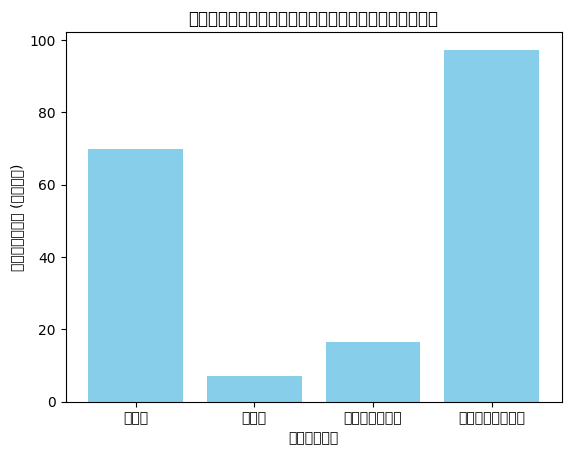

In [34]:
import matplotlib.pyplot as plt

# Create a bar chart for population
plt.bar(df['ประเทศ'], df['ประชากร (ล้าน)'], color='skyblue')
plt.title('จำนวนประชากรในแต่ละประเทศ')
plt.xlabel('ประเทศ')
plt.ylabel('ประชากร (ล้าน)')
plt.show()


### **4.2 การรวมข้อมูลเชิงพื้นที่และตาราง**
รวมข้อมูล Shapefile กับข้อมูลประชากรเพื่อแสดงข้อมูลประชากรในแต่ละจังหวัด โดยให้นักศึกษาทดลองหาข้อมูลเอง
    

In [ ]:

# รวมข้อมูล
merged_data = geo_data.merge(df, left_on='province', right_on='ประเทศ')

# แสดงผลข้อมูลในแผนที่
merged_data.plot(column='ประชากร (ล้าน)', cmap='OrRd', legend=True, figsize=(12, 8))
plt.title('ประชากรในแต่ละจังหวัด')
plt.show()


NameError: name 'geo_data' is not defined

In [21]:
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os
import shutil # For rmtree

# 1. Install a robust Thai font package
print("Updating apt-get and installing fonts-thai-tlwg...")
!sudo apt-get update -qq
!sudo apt-get install -y fonts-thai-tlwg -qq

# 2. Clear Matplotlib font cache directory
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"Cleared Matplotlib font cache directory: {cache_dir}")
else:
    print("Matplotlib font cache directory not found or already cleared.")

# Force Matplotlib to rebuild its font cache after installing new fonts
# It's important to reload the font manager after installing new fonts
fm._load_fontmanager(try_read_cache=False) # This method effectively rebuilds the cache
print("Matplotlib font cache rebuilt.")

# 3. Find and set a suitable Thai font
thai_font_name = None
# Look for any font containing 'tlwg' in its name, which should come from the installed package
for font_prop in fm.fontManager.ttflist:
    if 'tlwg' in font_prop.name.lower():
        thai_font_name = font_prop.name
        break

plt.rcParams['axes.unicode_minus'] = False # Disable unicode minus for proper display of negative signs

if thai_font_name:
    plt.rcParams['font.family'] = thai_font_name
    print(f"Successfully configured Matplotlib to use '{thai_font_name}'.")
else:
    print(f"Warning: No suitable Thai (tlwg) font found. Falling back to DejaVu Sans.")
    plt.rcParams['font.family'] = 'DejaVu Sans' # Fallback
    print("Thai characters might not display correctly.")

print("Matplotlib font configuration complete.")

Updating apt-get and installing fonts-thai-tlwg...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Matplotlib font cache directory not found or already cleared.


Matplotlib font cache rebuilt.
Thai characters might not display correctly.
Matplotlib font configuration complete.



## **โจทย์สำหรับนักศึกษา** 15 คะแนน
1. ลองเพิ่มประเทศใหม่ใน DataFrame พร้อมคำนวณความหนาแน่นประชากร (5 คะแนน)
2. นำไฟล์ Shapefile ของพื้นที่อื่นมาแสดงผลใน GeoPandas (5 คะแนน)
3. ลองสร้างแผนที่ด้วยสีที่แตกต่างกันโดยใช้ค่าอื่น เช่น `area` หรือ `density` (5 คะแนน)

---

### **หมายเหตุ**
- ดาวน์โหลดข้อมูลจากแหล่ง Open Data เช่น [World Bank Open Data](https://data.worldbank.org) หรือ [Thailand Data Catalog](https://data.go.th)
- ใส่เครดิตแหล่งข้อมูลในรายงานของคุณ
    

**ประเทศอังกฤษ -United Kingdom**

CSV ข้อมูลประชากร

In [ ]:
import pandas as pd # Import the pandas library

# ตัวอย่างการอ่านไฟล์ CSV
file_path = '/content/WB_WDI_SP_POP_TOTL.csv'
geo_df = pd.read_csv(file_path)

# ตรวจสอบข้อมูล
print(geo_df.head())
print(geo_df.info())

       STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VUT   
1  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VEN   
2  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VNM   
3  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      VIR   
4  datastructure  WB.DATA360:DS_DATA360(1.3)      I    A      PSE   

            INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0  WB_WDI_SP_POP_TOTL  _T  _T           _T           PS  ...   
1  WB_WDI_SP_POP_TOTL  _T  _T           _T           PS  ...   
2  WB_WDI_SP_POP_TOTL  _T  _T           _T           PS  ...   
3  WB_WDI_SP_POP_TOTL  _T  _T           _T           PS  ...   
4  WB_WDI_SP_POP_TOTL  _T  _T           _T           PS  ...   

  COMP_BREAKDOWN_2_LABEL COMP_BREAKDOWN_3_LABEL AGG_METHOD_LABEL  \
0         Not Applicable         Not Applicable   Not Applicable   
1         Not Applicable         Not Applicable   Not Applicable

.SHP พื้นที่ของประเทศอังกฤษ

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt

# อ่านไฟล์ Shapefile (GeoPandas สามารถอ่านไฟล์ .zip ที่มี Shapefile อยู่ข้างในได้โดยตรง)
# หากมีหลายเลเยอร์ในไฟล์ .zip และต้องการเลเยอร์เฉพาะ ให้ระบุ layer='ชื่อเลเยอร์' เพิ่มเติม
# Assuming the shapefile is directly in MyDrive. Adjust the path if it's in a subfolder.
shapefile_path = '/content/drive/MyDrive/PARNCP_DEC_2025_EW_BFC.shp'
geo_data = gpd.read_file(shapefile_path)

# แสดงข้อมูลเบื้องต้น
print(geo_data.head())
print(geo_data.crs)

  PARNCP25CD    PARNCP25NM PARNCP25NW    LAD25CD     LAD25NM   BNG_E   BNG_N  \
0  E04000001      Blackrod       None  E08000001      Bolton  361040  410661   
1  E04000002       Horwich       None  E08000001      Bolton  365741  411963   
2  E04000003  Westhoughton       None  E08000001      Bolton  365008  406179   
3  E04000004       Ringway       None  E08000003  Manchester  381192  384606   
4  E04000005   Saddleworth       None  E08000004      Oldham  400672  407034   

      LONG      LAT                              GlobalID  \
0 -2.59006  53.5911  f1571828-a243-44d9-ac1f-2167e3060411   
1 -2.51919  53.6031  979e7011-6cce-4103-8b1f-30d0925007b3   
2 -2.52962  53.5511  e7e2ff54-6fe0-4870-a5d2-43807f51c215   
3 -2.28405  53.3580  3c85b477-b098-42fe-b202-41f3a24ab3b9   
4 -1.99132  53.5599  1ca316f6-ed1a-4247-b2d6-c05f0c8d5f9d   

                                            geometry  
0  POLYGON ((360731.9 412842.7, 360755.61 412835....  
1  POLYGON ((366340.404 414544.797, 366235

คำนวณความหนาแน่นประชากรประเทศอังกฤษ






In [31]:
import pandas as pd

# สร้าง DataFrame สำหรับประเทศอังกฤษ
england_data = {
    'ประเทศ': ['อังกฤษ'],
    'ประชากร (ล้าน)': [56.0],
    'พื้นที่ (ตร.กม.)': [130000]
}
england_df_only = pd.DataFrame(england_data)

# คำนวณความหนาแน่นประชากรสำหรับประเทศอังกฤษ
england_df_only['ความหนาแน่นประชากร (คน/ตร.กม.)'] = england_df_only['ประชากร (ล้าน)'] * 1_000_000 / england_df_only['พื้นที่ (ตร.กม.)']

print("\nDataFrame สำหรับประเทศอังกฤษพร้อมความหนาแน่นประชากร:")
print(england_df_only)


DataFrame สำหรับประเทศอังกฤษพร้อมความหนาแน่นประชากร:
   ประเทศ  ประชากร (ล้าน)  พื้นที่ (ตร.กม.)  ความหนาแน่นประชากร (คน/ตร.กม.)
0  อังกฤษ            56.0            130000                      430.769231


แผนที่แสดงความหนาแน่น

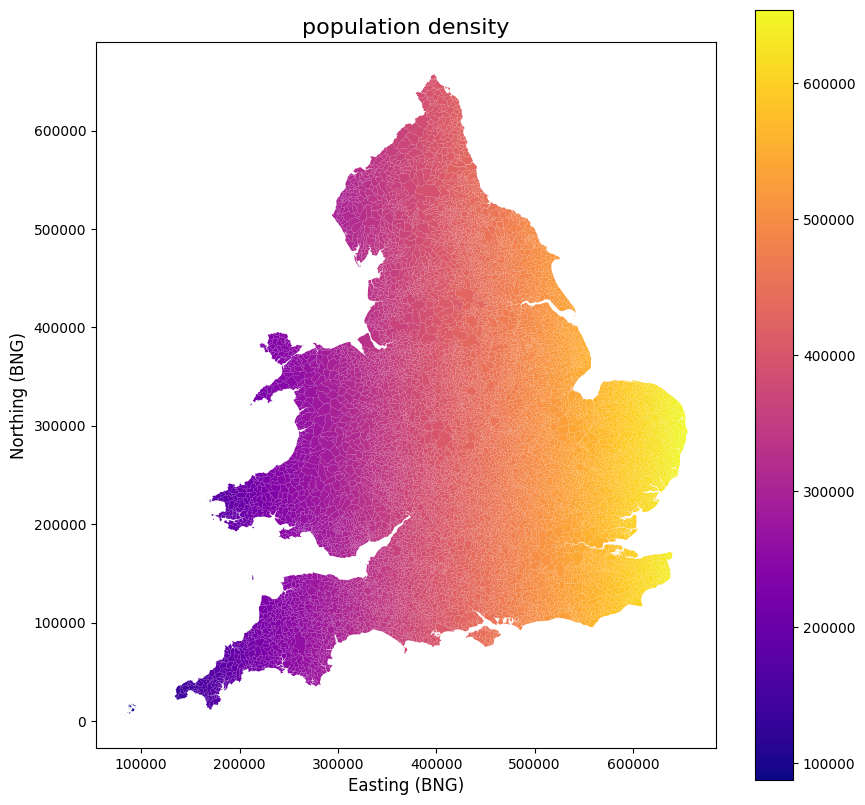

In [32]:
import matplotlib.pyplot as plt

# ตรวจสอบว่า geo_data ได้ถูกโหลดไว้แล้วใน Kernel
if 'geo_data' not in locals():
    print("Warning: 'geo_data' GeoDataFrame is not defined. Please ensure the cell for loading the England Shapefile was executed.")
    # Optionally, load it again if the user didn't run the previous cell
    import geopandas as gpd
    shapefile_path = '/content/PARNCP_DEC_2025_EW_BFC.shp'
    geo_data = gpd.read_file(shapefile_path)

# สร้างแผนที่แสดงการกระจายตัวของพื้นที่ในอังกฤษ
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
geo_data.plot(column='BNG_E', cmap='plasma', legend=True, ax=ax)
plt.title('population density', fontsize=16)
plt.xlabel('Easting (BNG)', fontsize=12)
plt.ylabel('Northing (BNG)', fontsize=12)
plt.show()

แหล่งข้อมูล
https://geoportal.statistics.gov.uk/search?q=BDY_PARNCP%20DEC_2025&sort=Title%7Ctitle%7Casc
https://population.un.org/wpp/